# Usar Jupyter en Odoo.

Para probar métodos del ORM y otras cosas en Odoo, podemos ejecutar la terminal de Odoo con “shell” en la línea de comandos.

No obstante eso puede ser un poco incómodo si queremos hacer pruebas más complejas, documentar o usar esa terminal para fines educativos. 

Jupyter es un entorno de programación y documentación integrado. Produce una página web donde se puede programar en Python de forma interactiva y ver el resultado. 

Veremos cómo probar Odoo dentro de Jupyter para hacer tutoriales o usarlo en clase. 

<div class="alert alert-block alert-info">
    Lo que podremos hacer estará limitado por la propia librería odooRPC o por XML-RPC.
</div>

Odoo cuando arranca establece un entorno muy complejo. Jupyter en principio sólo está preparado para ejecutar Python “vanilla” e ir incorporando librerias. 

Una forma cómoda de instalar Jupyter y usarlo después es instalar Anaconda. En el caso de Linux, hay que seguir los pasos de la web i luego ejecutar anaconda-navigator en la terminal. 
En caso de no querer Anaconda, podemos ejecutar:
```
sudo pip install notebook
jupyter notebook

```

## Con OdooRPC 

Para conectar el entorno de ejecución de Jupyter con Odoo, podemos usar su RPC. Hay una librería llamada OdooRPC https://pythonhosted.org/OdooRPC/ que facilita el uso del RPC de Odoo.

Para instalarla: 
```
pip install odoorpc 
```

Esta libería és externa al proyecto Odoo y simplifica la conexión por XML-RPC, la cual explicaremos más adelante por si se queda corta esta librería.

Veamos los diferentes comandos

In [8]:
import odoorpc

ModuleNotFoundError: No module named 'odoorpc'

Después de importar la librería, nos conectamos al servidor que corresponda:

<div class="alert alert-block alert-info">
  Por supuesto, las IP, usuarios, contraseñas y bases de datos hay que adaptarlos a los que tenga cada uno.
</div>


In [3]:
odoo = odoorpc.ODOO('192.168.88.29', port=8069)

In [5]:
print(odoo.db.list())

['proves']


Como vemos, podemos listar las bases de datos a las que tenemos acceso. 
Ahora nos conectaremos con la sintaxis:

```odoo.login('db_name', 'user', 'passwd')```

In [6]:
odoo.login('proves', 'admin', '1234')

Una vez conectado, podemos hacer lo que queramos. Aquí hay varios ejemplos:

Obtener información del usuario:

In [7]:
user = odoo.env.user
print(user.name)            # name of the user connected
print(user.company_id.name) # the name of its company

Mitchell Admin
My Company (San Francisco)


Obtener toda la información del usuario. 

In [8]:
user_data = odoo.execute('res.users', 'read', [user.id])
print(user_data)

[{'id': 2, 'partner_id': [3, 'YourCompany, Mitchell Admin'], 'login': 'admin', 'password': '', 'new_password': '', 'signature': '<span data-o-mail-quote="1">-- <br data-o-mail-quote="1">\nAdministrator</span>', 'active': True, 'active_partner': True, 'action_id': False, 'groups_id': [2, 11, 7, 47, 39, 22, 56, 26, 28, 8, 1, 48, 18, 4, 37, 41, 3, 23, 6, 38, 46, 55, 21, 20], 'log_ids': [10, 9], 'login_date': '2022-02-14 16:19:32', 'share': False, 'companies_count': 3, 'tz_offset': '+0100', 'company_id': [1, 'My Company (San Francisco)'], 'company_ids': [3, 4, 1], 'accesses_count': 690, 'rules_count': 63, 'groups_count': 24, 'totp_enabled': False, 'totp_trusted_device_ids': [], 'api_key_ids': [], 'im_status': 'offline', 'resource_ids': [], 'resource_calendar_id': False, 'notification_type': 'email', 'is_moderator': False, 'moderation_counter': 0, 'moderation_channel_ids': [], 'state': 'active', 'odoobot_state': 'disabled', 'odoobot_failed': False, 'sale_team_id': [1, 'Europe'], 'target_sal

En este caso, busca el modelo sale.order y hace una búsqueda sin criterio de búsqueda para que salgan todas y para cada una obtiene la lista de los productos:

In [9]:
if 'sale.order' in odoo.env:
    Order = odoo.env['sale.order']
    order_ids = Order.search([])
    for order in Order.browse(order_ids):
        print(order.name)
        products = [line.product_id.name for line in order.order_line]
        print(products)

S00022
['Pantallas de bloque acústico', 'Gabinete con puertas']
S00021
['Pantallas de bloque acústico']
S00020
['Pantallas de bloque acústico', 'Gabinete con puertas']
S00015
['Pantallas de bloque acústico', 'Silla de oficina negra']
S00013
['Pantallas de bloque acústico', 'Silla de oficina negra']
S00012
['Pantallas de bloque acústico', 'Silla de oficina negra']
S00011
['Pantallas de bloque acústico', 'Silla de oficina negra']
S00009
['Pantallas de bloque acústico', 'Silla de oficina negra']
Test/001
['Cajón', 'Silla de oficina negra']
S00007
['Pantallas de bloque acústico', 'Sofá de tres asientos', 'Lámpara de oficina', 'Silla de oficina']
S00006
['Escritorio personalizable (CONFIG)']
S00004
['Diseño interior virtual', 'Lámpara de oficina', 'Gran mesa de reuniones', 'Silla de oficina']
S00003
['Diseño interior virtual', 'Silla de oficina']
S00008
['Cajón', 'Silla de oficina negra']
S00014
['Pantallas de bloque acústico', 'Silla de oficina negra']
S00010
['Pantallas de bloque acústico

Ejemplo de cómo cambiar el valor a un registro:

In [14]:
user.name = "Jose"

In [15]:
user

Recordset('res.users', [2])

In [16]:
user.name

'Jose'

Ejemplo de buscar datos concretos sobre productos. 

In [26]:
product_model = odoo.env['product.product']

In [27]:
product_ids = product_model.search([])

In [38]:
product_raw = product_model.read(product_ids)
product_raw

[{'id': 52,
  'price': 0.0,
  'price_extra': 0.0,
  'lst_price': 1.2,
  'default_code': 'CONS_0001',
  'code': 'CONS_0001',
  'partner_ref': '[CONS_0001] Pluma de Pizarra',
  'active': True,
  'product_tmpl_id': [42, '[CONS_0001] Pluma de Pizarra'],
  'barcode': False,
  'product_template_attribute_value_ids': [],
  'combination_indices': '',
  'is_product_variant': True,
  'standard_price': 0.0,
  'volume': 0.0,
  'weight': 0.01,
  'pricelist_item_count': 0,
  'packaging_ids': [],
  'image_variant_1920': False,
  'image_variant_1024': False,
  'image_variant_512': False,
  'image_variant_256': False,
  'image_variant_128': False,
  'can_image_variant_1024_be_zoomed': False,
  'image_1920': '...',
  'image_1024': '...',
  'image_512': '...',
  'image_256': '...',
  'image_128': 'iVBORw0KGgoAAAANSUhEUgAAAH4AAACACAMAAAD6ZS3TAAADAFBMVEX////+/v7AwMDx7/Pf39/j4+Pc3Nz///7h4eHd3d3u6vDk5OW8vLzx6/H07vS3uLe6urrr6uP07+/Dw8Ln5+Ln5+bs6ub38fC+vr7y8fTh4d2wr6/c4NsxLzHq5+i0tLT37vXs6u3e3t/v6OTv7fLX2NU2Mz

In [40]:
product_recordset = product_model.browse(product_ids)
product_data = product_recordset.read(['id','name','list_price','type'])

<div class="alert alert-block alert-info">
No obstante, la librería de odooRPC se limita a poder hacer search(), browse() y read() y poco más sobre los recordsets. Instrucciones más complejas del ORM como filtered, mapped o sorted no se pueden ejecutar.</div> 

Ahora vamos a algo más interesante y relacionado con lo que típicamente se hace com Jupyter, el análisis de datos. Para ello importaremos la libreía Pandas y mostraremos algunos datos:

In [18]:
import pandas as pd

In [41]:
pd.DataFrame(product_data).set_index('id')

,name,list_price,type
id,,,
52,Pluma de Pizarra,1.20,consu
15,Escritorio personalizable (CONFIG),750.00,product
37,Escritorio personalizable (CONFIG),750.00,product
38,Escritorio personalizable (CONFIG),750.00,product
41,Descuento,0.00,consu
...,...,...,...
49,Pizarra,1.70,product
67,Salmon and Avocado,9.25,consu
61,Spicy Tuna Sandwich,3.00,consu


<AxesSubplot:xlabel='id'>

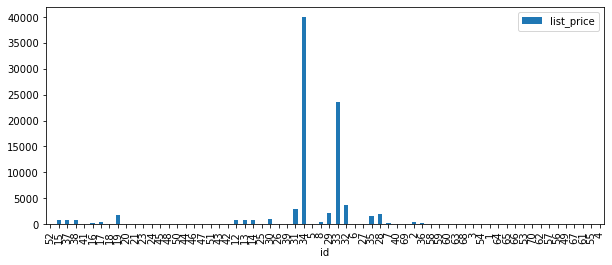

In [43]:
pd.DataFrame(product_data).set_index('id').plot(kind='bar',figsize=(10,4))

In [32]:
pd.DataFrame(product_data).set_index('id').describe()

,list_price
count,68.000000
mean,1254.674706
std,5579.378798
min,0.000000
25%,3.347500
50%,14.000000
75%,340.000000
max,40000.000000


## Con XML-RPC

Si queremos acceder diréctamente a Odoo por su API, debemos conectarnos por XML-RPC. Eso es lo que hace la librería explicada anteriormente. Haciéndolo directamente puede que tengamos más opciones. Veamos cómo conectar:

In [9]:
import xmlrpc.client

url = 'http://192.168.8.220:8069'
db = 'sge23'
username = 'admin'
password = '1234'
# El password puede ser una API Key generada desde el própio odoo

common = xmlrpc.client.ServerProxy('{}/xmlrpc/2/common'.format(url))
common.version()


{'server_version': '15.0-20220920',
 'server_version_info': [15, 0, 0, 'final', 0, ''],
 'server_serie': '15.0',
 'protocol_version': 1}

In [11]:
# Autenticar la conexión
uid = common.authenticate(db, username, password, {})
print(uid)

2


Para hacer peticiones, debemos ejecutar la funció RPC `execute_kw`.


In [13]:
models = xmlrpc.client.ServerProxy('{}/xmlrpc/2/object'.format(url))
# Consulta de los derechos de acceso. 
models.execute_kw(db, uid, password, 'res.partner', 'check_access_rights', ['read'], {'raise_exception': False})


True

In [14]:
# Búsqueda de los clientes que son compañias.
models.execute_kw(db, uid, password, 'res.partner', 'search', [[['is_company', '=', True]]])

[14, 10, 11, 15, 12, 13, 9, 1]

In [17]:
# Leer los datos de unos clientes.
ids = models.execute_kw(db, uid, password, 'res.partner', 'search', [[['is_company', '=', True]]], {'limit': 1})
[record] = models.execute_kw(db, uid, password, 'res.partner', 'read', [ids])
# Contar la cantidad de clientes
print(len(record))
#print(record)
models.execute_kw(db, uid, password, 'res.partner', 'read', [ids], {'fields': ['name', 'country_id', 'comment']})

155


[{'id': 14,
  'name': 'Azure Interior',
  'country_id': [233, 'United States'],
  'comment': False}]

In [18]:
# Buscar y leer: 
models.execute_kw(db, uid, password, 'res.partner', 
                  'search_read', [[['is_company', '=', True]]], 
                  {'fields': ['name', 'country_id', 'comment'], 'limit': 5})


[{'id': 14,
  'name': 'Azure Interior',
  'country_id': [233, 'United States'],
  'comment': False},
 {'id': 10,
  'name': 'Deco Addict',
  'country_id': [233, 'United States'],
  'comment': '<p><br></p>'},
 {'id': 11,
  'name': 'Gemini Furniture',
  'country_id': [233, 'United States'],
  'comment': False},
 {'id': 15,
  'name': 'Lumber Inc',
  'country_id': [233, 'United States'],
  'comment': False},
 {'id': 12,
  'name': 'Ready Mat',
  'country_id': [233, 'United States'],
  'comment': False}]

In [19]:
# Crear Nuevos clientes:
id = models.execute_kw(db, uid, password, 'res.partner', 'create', [{'name': "New Partner"}])

In [20]:
# Modificar:
models.execute_kw(db, uid, password, 'res.partner', 'write', [[id], {'name': "Newer partner"}])

True

In [21]:
# Borrar: 
models.execute_kw(db, uid, password, 'res.partner', 'unlink', [[id]])

True

## Con JSON-RPC:

Odoo también permite acceder diréctamente con JSON. 

Usa https://www.jsonrpc.org/specification :


In [2]:
import json
import random
import urllib.request

HOST = 'odoo'
PORT = 8069
DB = 'fncv'
USER = 'admin'
PASS = 'admin'

def json_rpc(url, method, params):
    data = {
        "jsonrpc": "2.0",
        "method": method,
        "params": params,
        "id": random.randint(0, 1000000000),
    }
    print(json.dumps(data).encode())
    req = urllib.request.Request(url=url, data=json.dumps(data).encode(), headers={
        "Content-Type":"application/json",
    })
    reply = json.loads(urllib.request.urlopen(req).read().decode('UTF-8'))
    if reply.get("error"):
        raise Exception(reply["error"])
    return reply["result"]

def call(url, service, method, *args):
    return json_rpc(url, "call", {"service": service, "method": method, "args": args})

# log in the given database
url = "http://%s:%s/jsonrpc" % (HOST, PORT)
uid = call(url, "common", "login", DB, USER, PASS)

# create a new note
args = []
clients = call(url, "object", "execute", DB, uid, PASS, 'res.partner', 'search', args)
print(clients)

b'{"jsonrpc": "2.0", "method": "call", "params": {"service": "common", "method": "login", "args": ["fncv", "admin", "admin"]}, "id": 651838287}'
b'{"jsonrpc": "2.0", "method": "call", "params": {"service": "object", "method": "execute", "args": ["fncv", 2, "admin", "res.partner", "search", []]}, "id": 534002356}'
[15, 27, 34, 28, 10, 36, 19, 20, 11, 21, 23, 32, 24, 16, 35, 13, 12, 22, 26, 38, 25, 37, 31, 39, 14, 30, 29, 9, 18, 33, 17, 1, 40, 41, 8, 7, 3, 43]


Si observamos lo que envía al servidor, es un JSON en un determinado formato. Informa del método "call" y los parámetros como indica el estándar JSON-RPC https://www.jsonrpc.org/specification.

A continuación, en los "params" es donde hay que especificar la petición RPC a Odoo. En el primer ejemplo lo envía al "service" "common" para hacer "login" y les envía los argumentos que el login necesita. 

Aquí podemos encontrar información, aunque sea de XML-RPC: https://www.odoo.com/documentation/14.0/developer/reference/external_api.html 

Después, en el "service" "object" le pedimos que ejecute un método del ORM. En este caso es el método "search". El resto de argumentos lo pasamos en un array, ya que los necesita de forma posicional. 

## Read

En el siguiente ejemplo hacemos lo mismo, pero con el método "read", pero vemos que los argumentos los pasa en el mismo órden que el search anterior: base de datos, uid, password, modelo, método ORM, argumentos, en este caso necesita dos argumentos, un array de ids y los fields que va a tener que leer. 

In [3]:

clients_data = call(url, "object", "execute", DB, uid, PASS, 'res.partner', 'read', [14,26],['name', 'country_id', 'comment'])
print(clients_data)

b'{"jsonrpc": "2.0", "method": "call", "params": {"service": "object", "method": "execute", "args": ["fncv", 2, "admin", "res.partner", "read", [14, 26], ["name", "country_id", "comment"]]}, "id": 353616449}'
[{'id': 14, 'name': 'The Jackson Group', 'country_id': [233, 'United States'], 'comment': False}, {'id': 26, 'name': 'Edith Sanchez', 'country_id': [233, 'United States'], 'comment': False}]


Veamos ahora un ejemplo para cada función típica del ORM de Odoo:

## Create

In [4]:
new_partner = call(url, "object", "execute", DB, uid, PASS, 'res.partner', 'create', {"name": "pepe"})

b'{"jsonrpc": "2.0", "method": "call", "params": {"service": "object", "method": "execute", "args": ["fncv", 2, "admin", "res.partner", "create", {"name": "pepe"}]}, "id": 769997439}'


In [5]:
print(new_partner)

44


In [6]:
partner_data = call(url, "object", "execute", DB, uid, PASS, 'res.partner', 'read', [new_partner],['name', 'country_id', 'comment'])
print(partner_data)

b'{"jsonrpc": "2.0", "method": "call", "params": {"service": "object", "method": "execute", "args": ["fncv", 2, "admin", "res.partner", "read", [44], ["name", "country_id", "comment"]]}, "id": 17544396}'
[{'id': 44, 'name': 'pepe', 'country_id': False, 'comment': False}]


## Write
Para actualizar un registro

In [20]:
call(url, "object", "execute", DB, uid, PASS, 'res.partner', 'write', new_partner, {"name": "pepe2"})

b'{"jsonrpc": "2.0", "method": "call", "params": {"service": "object", "method": "execute", "args": ["roma", 2, "1234", "res.partner", "write", 70, {"name": "pepe2"}]}, "id": 118774873}'


True

In [21]:
partner_data = call(url, "object", "execute", DB, uid, PASS, 'res.partner', 'read', [new_partner],['name', 'country_id', 'comment'])
print(partner_data)

b'{"jsonrpc": "2.0", "method": "call", "params": {"service": "object", "method": "execute", "args": ["roma", 2, "1234", "res.partner", "read", [70], ["name", "country_id", "comment"]]}, "id": 588047109}'
[{'id': 70, 'name': 'pepe2', 'country_id': False, 'comment': False}]


## unlink

In [16]:
call(url, "object", "execute", DB, uid, PASS, 'res.partner', 'unlink', [new_partner])
partner_data = call(url, "object", "execute", DB, uid, PASS, 'res.partner', 'read', [new_partner],['name', 'country_id', 'comment'])
print(partner_data)

b'{"jsonrpc": "2.0", "method": "call", "params": {"service": "object", "method": "execute", "args": ["roma", 2, "1234", "res.partner", "unlink", [69]]}, "id": 472269841}'
b'{"jsonrpc": "2.0", "method": "call", "params": {"service": "object", "method": "execute", "args": ["roma", 2, "1234", "res.partner", "read", [69], ["name", "country_id", "comment"]]}, "id": 442668397}'
[]


## Search & read


In [3]:
clients = call(url, "object", "execute", DB, uid, PASS, 'res.partner', 'search', [["name","=","pepe"]])
print(clients)
clients_data = call(url, "object", "execute", DB, uid, PASS, 'res.partner', 'read', clients,['name', 'country_id', 'comment'])
print(clients_data)

b'{"jsonrpc": "2.0", "method": "call", "params": {"service": "object", "method": "execute", "args": ["roma", 2, "1234", "res.partner", "search", [["name", "=", "pepe"]]]}, "id": 25279074}'
[68]
b'{"jsonrpc": "2.0", "method": "call", "params": {"service": "object", "method": "execute", "args": ["roma", 2, "1234", "res.partner", "read", [68], ["name", "country_id", "comment"]]}, "id": 305891113}'
[{'id': 68, 'name': 'pepe', 'country_id': False, 'comment': False}]


### Search Read con paginación

En este caso, en el search, enviamos los parámetros 2 y 5 como offset (2) y limit (5). En el manual de xml-rpc oficial de odoo lo ponen como {'offset': 10, 'limit': 5}, esto funciona en ese protocolo, pero en este es a más bajo nivel y espera diréctamente los parámetros. 

In [11]:
clients = call(url, "object", "execute", DB, uid, PASS, 'res.partner', 'search', [], 2, 5)
print(clients)
clients_data = call(url, "object", "execute", DB, uid, PASS, 'res.partner', 'read', clients,['name'])
print(clients_data)

b'{"jsonrpc": "2.0", "method": "call", "params": {"service": "object", "method": "execute", "args": ["roma", 2, "1234", "res.partner", "search", [], 2, 5]}, "id": 214958100}'
[33, 27, 10, 35, 18]
b'{"jsonrpc": "2.0", "method": "call", "params": {"service": "object", "method": "execute", "args": ["roma", 2, "1234", "res.partner", "read", [33, 27, 10, 35, 18], ["name"]]}, "id": 211637296}'
[{'id': 33, 'name': 'Colleen Diaz'}, {'id': 27, 'name': 'Nicole Ford'}, {'id': 10, 'name': 'Deco Addict'}, {'id': 35, 'name': 'Addison Olson'}, {'id': 18, 'name': 'Douglas Fletcher'}]


### Search_read con el método específico y paginación
En este caso, Odoo tiene ya un search_read. Los primeros [] después del método es para los criterios de búsqueda, como en el ejemplos de search. Los siguientes son los "fields" a recuperar. 

In [7]:
clients = call(url, "object", "execute", DB, uid, PASS, 'res.partner', 'search_read', [],['name'], 2, 5)
print(clients)


b'{"jsonrpc": "2.0", "method": "call", "params": {"service": "object", "method": "execute", "args": ["fncv", 2, "admin", "res.partner", "search_read", [], ["name"], 2, 5]}, "id": 319180785}'
[{'id': 34, 'name': 'Colleen Diaz'}, {'id': 28, 'name': 'Nicole Ford'}, {'id': 10, 'name': 'Deco Addict'}, {'id': 36, 'name': 'Addison Olson'}, {'id': 19, 'name': 'Douglas Fletcher'}]


## Search & Count
Para contar la cantidad de registros encontrados

In [14]:
clients = call(url, "object", "execute", DB, uid, PASS, 'res.partner', 'search_count', [])
print(clients)

b'{"jsonrpc": "2.0", "method": "call", "params": {"service": "object", "method": "execute", "args": ["roma", 2, "1234", "res.partner", "search_count", []]}, "id": 261125097}'
38


## Listar atributos

In [20]:
clients_fields = call(url, "object", "execute", DB, uid, PASS, 'res.partner', 'fields_get', [])
print(clients_fields)

b'{"jsonrpc": "2.0", "method": "call", "params": {"service": "object", "method": "execute", "args": ["roma", 2, "1234", "res.partner", "fields_get", []]}, "id": 125849546}'
{'message_is_follower': {'change_default': False, 'company_dependent': False, 'default_export_compatible': False, 'depends': ['message_follower_ids'], 'exportable': True, 'manual': False, 'name': 'message_is_follower', 'readonly': True, 'required': False, 'searchable': True, 'sortable': False, 'store': False, 'string': 'Is Follower', 'type': 'boolean'}, 'message_follower_ids': {'change_default': False, 'company_dependent': False, 'context': {}, 'default_export_compatible': False, 'depends': [], 'domain': [], 'exportable': True, 'groups': 'base.group_user', 'manual': False, 'name': 'message_follower_ids', 'readonly': False, 'relation': 'mail.followers', 'relation_field': 'res_id', 'required': False, 'searchable': True, 'sortable': False, 'store': True, 'string': 'Followers', 'type': 'one2many'}, 'message_partner_ids'

Este retorna todos los fields, y de ellos, todos los atributos, que pueden ser demasiados. Con el siguiente le pedimos un field en concreto

In [8]:
clients_fields = call(url, "object", "execute", DB, uid, PASS, 'res.partner', 'fields_get', ['name'])
print(clients_fields)

b'{"jsonrpc": "2.0", "method": "call", "params": {"service": "object", "method": "execute", "args": ["fncv", 2, "admin", "res.partner", "fields_get", ["name"]]}, "id": 417362777}'
{'name': {'change_default': False, 'company_dependent': False, 'default_export_compatible': True, 'depends': [], 'exportable': True, 'groupable': True, 'manual': False, 'name': 'name', 'readonly': False, 'required': False, 'searchable': True, 'sortable': True, 'store': True, 'string': 'Name', 'translate': False, 'trim': True, 'type': 'char'}}


In [9]:
clients_fields = call(url, "object", "execute", DB, uid, PASS, 'res.partner', 'fields_get', ['name'], ['string', 'type'])
print(clients_fields)

b'{"jsonrpc": "2.0", "method": "call", "params": {"service": "object", "method": "execute", "args": ["fncv", 2, "admin", "res.partner", "fields_get", ["name"], ["string", "type"]]}, "id": 345609753}'
{'name': {'string': 'Name', 'type': 'char'}}


 ## Autenticación con Odoo y JSON-RPC
 
 Supongamos que queremos hacer una aplicación para consultar datos de Odoo o usarlo como método de autenticación de usuarios.
 Los usuarios están en res.users y Odoo ya tiene su sistema de autenticación en el "Service" "Common". Este no es necesario siempre, ya que cualquier petición es "stateless" y necesita que enviemos el usuario y contraseña. Pero hace falta para saber el "uid" del usuario que va a hacer la petición.

In [23]:
uid = call(url, "common", "login", DB, USER, PASS)
print("User:", uid)

b'{"jsonrpc": "2.0", "method": "call", "params": {"service": "common", "method": "login", "args": ["roma", "admin", "1234"]}, "id": 754521245}'
User: 2


### Crear usuarios
Puede que necesitemos crear usuarios desde una aplicación externa. 

In [25]:
new_user = call(url, "object", "execute", DB, uid, PASS, 'res.users', 'create', {"name": "New User", "login": "new_user", "password": "1234", "email": "new@email.com"})

b'{"jsonrpc": "2.0", "method": "call", "params": {"service": "object", "method": "execute", "args": ["roma", 2, "1234", "res.users", "create", {"name": "New User", "login": "new_user", "password": "1234", "email": "new@email.com"}]}, "id": 595415685}'


In [26]:
print(new_user)

35


Esto crea automáticamente un nuevo "res.partner" que podemos utilizar como cliente. Podemos saber el id del "res.partner" inspeccionando el field many2one que los relaciona:

In [31]:
user_data = call(url, "object", "execute", DB, uid, PASS, 'res.users', 'read', [new_user],['login', 'partner_id'])
print(user_data)

b'{"jsonrpc": "2.0", "method": "call", "params": {"service": "object", "method": "execute", "args": ["roma", 2, "1234", "res.users", "read", [35], ["login", "partner_id"]]}, "id": 751902356}'
[{'id': 35, 'login': 'new_user', 'partner_id': [71, 'New User']}]


In [32]:
partner_id = user_data[0]['partner_id'][0]
print(partner_id)

71


Veamos cómo se puede hacer login con el nuevo usuario:

In [33]:
uid_new_user = call(url, "common", "login", DB, 'new_user', '1234')
print("User:", uid_new_user)

b'{"jsonrpc": "2.0", "method": "call", "params": {"service": "common", "method": "login", "args": ["roma", "new_user", "1234"]}, "id": 671523811}'
User: 35


## Gestión de ventas con JSON-RPC
En este caso vamos a implementar un proceso muy común. Supongamos que queremos crear una venta desde una aplicación externa. 
El modelos es "sale.order" y cada línea es "sale.order.line". Por otro lado, los productos a vender están en "product.product". 
Lo primero que haremos será listar los productos, mostraremos los primeros 5:

In [10]:
products = call(url, "object", "execute", DB, uid, PASS, 'product.product', 'search_read', [],['name'], 0, 5)
print(products)

b'{"jsonrpc": "2.0", "method": "call", "params": {"service": "object", "method": "execute", "args": ["fncv", 2, "admin", "product.product", "search_read", [], ["name"], 0, 5]}, "id": 237871116}'
[{'id': 44, 'name': 'Customizable Desk'}, {'id': 45, 'name': 'Customizable Desk'}, {'id': 37, 'name': 'Local Delivery'}, {'id': 16, 'name': 'Corner Desk Right Sit'}, {'id': 17, 'name': 'Large Cabinet'}]


Imaginemos que el cliente elige el 1er producto:

In [11]:
product = products[0]['id']
print("Product:",product)

Product: 44


Suponiendo que el cliente es el creado anteriormente, vamos a hacer una venta:

In [13]:
sale = call(url, "object", "execute", DB, uid, PASS, 'sale.order', 'create', {"partner_id": uid})
print("Sale Order", sale)

b'{"jsonrpc": "2.0", "method": "call", "params": {"service": "object", "method": "execute", "args": ["fncv", 2, "admin", "sale.order", "create", {"partner_id": 2}]}, "id": 913102676}'
Sale Order 37


In [14]:
sale_line = call(url, "object", "execute", DB, uid, PASS, 'sale.order.line', 'create', {
    "order_id": sale, 
    "product_id": product,
    "product_uom_qty": 3
})
print(sale_line)

b'{"jsonrpc": "2.0", "method": "call", "params": {"service": "object", "method": "execute", "args": ["fncv", 2, "admin", "sale.order.line", "create", {"order_id": 37, "product_id": 44, "product_uom_qty": 3}]}, "id": 258999937}'
53


Cuando se hace un pedido en Odoo, este tiene diversos estados: Presupuesto, Pedido, Pedido pagado/entregado.., Factura, Factura Pagada. 
De momento hemos creado un presupuesto. Vamos a crear la factura y a suponer que se ha pagado. El proceso intermedio lo podría estar haciendo la aplicación externa.
El que un presupuesto pase a pedido no es tan sólo cambiar su campo "state". El modelo "sale.order" tiene un método específico "action_confirm"

In [15]:
call(url, "object", "execute", DB, uid, PASS, 'sale.order', 'action_confirm', [sale])

b'{"jsonrpc": "2.0", "method": "call", "params": {"service": "object", "method": "execute", "args": ["fncv", 2, "admin", "sale.order", "action_confirm", [37]]}, "id": 771862523}'


True

Ahora queremos hacer la factura, pero antes hay que indicar que está todo entregado:

In [82]:
sale_lines =  call(url, "object", "execute", DB, uid, PASS, 'sale.order', 'read', [sale],['order_line'])[0]['order_line']
print(sale_lines)

b'{"jsonrpc": "2.0", "method": "call", "params": {"service": "object", "method": "execute", "args": ["roma", 2, "1234", "sale.order", "read", [37], ["order_line"]]}, "id": 512544583}'
[72]


In [83]:
quantities = call(url, "object", "execute", DB, uid, PASS, 'sale.order.line', 'read', sale_lines,['product_uom_qty'])
print(quantities)

b'{"jsonrpc": "2.0", "method": "call", "params": {"service": "object", "method": "execute", "args": ["roma", 2, "1234", "sale.order.line", "read", [72], ["product_uom_qty"]]}, "id": 815155193}'
[{'id': 72, 'product_uom_qty': 3.0}]


In [84]:
for s in quantities:
    call(url, "object", "execute", DB, uid, PASS, 'sale.order.line', 'write', s['id'], {"qty_delivered": s['product_uom_qty']})

b'{"jsonrpc": "2.0", "method": "call", "params": {"service": "object", "method": "execute", "args": ["roma", 2, "1234", "sale.order.line", "write", 72, {"qty_delivered": 3.0}]}, "id": 461566654}'


Crear una factura a partir de un "sale.order" no es una tarea sencilla. Odoo proporciona un Wizard con varias opciones y con todo eso llama a una función. La función está implementada en propio wizard y es muy compleja (https://github.com/odoo/odoo/blob/17.0/addons/sale/wizard/sale_make_invoice_advance.py#L195)
Por ello, lo más cómodo puede ser crear un wizard (el transient model) y luego llamar a la función

In [85]:
invoice_wizard = call(url, "object", "execute", DB, uid, PASS, 'sale.advance.payment.inv', 'create', 
                      {"sale_order_ids": [sale]}
                     )
print(invoice_wizard)

b'{"jsonrpc": "2.0", "method": "call", "params": {"service": "object", "method": "execute", "args": ["roma", 2, "1234", "sale.advance.payment.inv", "create", {"sale_order_ids": [37]}]}, "id": 447156165}'
7


In [86]:
invoice = call(url, "object", "execute", DB, uid, PASS, 'sale.advance.payment.inv', 'create_invoices', [invoice_wizard])

b'{"jsonrpc": "2.0", "method": "call", "params": {"service": "object", "method": "execute", "args": ["roma", 2, "1234", "sale.advance.payment.inv", "create_invoices", [7]]}, "id": 726235557}'


In [87]:
print(invoice)

{'type': 'ir.actions.act_window_close'}


Como se puede ver, la factura creada no es retornada por la función, pero la podemos consultar de nuevo desde sale.order:


In [88]:
invoice =  call(url, "object", "execute", DB, uid, PASS, 'sale.order', 'read', [sale],['invoice_ids'])[0]['invoice_ids'][0]
print(invoice)

b'{"jsonrpc": "2.0", "method": "call", "params": {"service": "object", "method": "execute", "args": ["roma", 2, "1234", "sale.order", "read", [37], ["invoice_ids"]]}, "id": 859188960}'
37


Ahora hay que confirmar la factura:

In [89]:
call(url, "object", "execute", DB, uid, PASS, 'account.move', 'action_post', [invoice])

b'{"jsonrpc": "2.0", "method": "call", "params": {"service": "object", "method": "execute", "args": ["roma", 2, "1234", "account.move", "action_post", [37]]}, "id": 441705469}'


False

Ahora habría que registrar el pago, lo cual es similar a crear la factura, ya que Odoo lo hace con un wizard. 

Una vez hecha la factura hay que descargarla en PDF. Odoo utiliza un software externo llamado Wkhtmltopdf que debería estar instalado en el sistema. En caso de querer una vista prévia en HTML, podemos ir a la URL que también proporciona Odoo, en este caso: http://localhost:8069/report/html/account.report_invoice/36 siendo 36 el id de la invoice creada. En esta url tenemos la versión pdf si está instalado Wkhtmltopdf: http://localhost:8069/report/pdf/account.report_invoice/36